### Types of Outliers

* Global Outliers  
*A single data point that deviates significantly from the entire dataset*
* Contextual Outliers  
*A data point that is considered anomalous only within a specific context or condition, but might be completely normal elsewhere*
* Collective Outliers   
*A subset or group of data points that collectively deviate from the whole dataset, even if the individual data points within that group look normal on their own*

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [5]:
df = pd.read_csv('data/glass.csv')
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


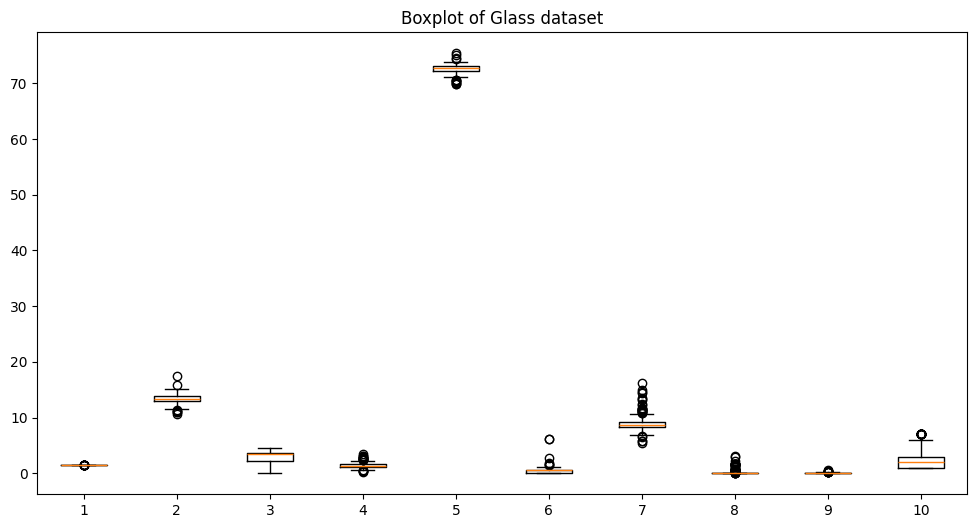

In [6]:
plt.figure(figsize=(12, 6))
plt.boxplot(df)
plt.title('Boxplot of Glass dataset')
plt.show()

### Outliers Detection Methods

#### Z-Score Method

In [7]:
z_scores = np.abs(stats.zscore(df))

In [8]:
z_scores

array([[0.87286765, 0.28495326, 1.25463857, ..., 0.35287683, 0.5864509 ,
        0.84827468],
       [0.24933347, 0.59181718, 0.63616803, ..., 0.35287683, 0.5864509 ,
        0.84827468],
       [0.72131806, 0.14993314, 0.60142249, ..., 0.35287683, 0.5864509 ,
        0.84827468],
       ...,
       [0.75404635, 1.16872135, 1.86551055, ..., 2.95320036, 0.5864509 ,
        2.01047778],
       [0.61239854, 1.19327046, 1.86551055, ..., 2.81208731, 0.5864509 ,
        2.01047778],
       [0.41436305, 1.00915211, 1.86551055, ..., 3.01367739, 0.5864509 ,
        2.01047778]], shape=(214, 10))

In [9]:
outliers = np.where(z_scores > 3)

In [10]:
outliers

(array([105, 106, 106, 106, 106, 106, 107, 107, 107, 110, 111, 112, 112,
        131, 145, 162, 163, 163, 163, 171, 171, 172, 172, 174, 184, 184,
        188, 189, 201, 201, 203, 207, 213]),
 array([6, 0, 1, 4, 6, 7, 0, 4, 6, 6, 6, 0, 6, 6, 8, 8, 3, 4, 7, 3, 5, 3,
        5, 8, 1, 4, 4, 7, 4, 5, 7, 7, 7]))

In [11]:
for i, j in zip(outliers[0], outliers[1]):
    print(
        f"Row: {df.index[i]}, "
        f"Column: {df.columns[j]}, "
        f"Value: {df.iloc[i, j]}"
    )

Row: 105, Column: Ca, Value: 13.24
Row: 106, Column: RI, Value: 1.53125
Row: 106, Column: Na, Value: 10.73
Row: 106, Column: Si, Value: 69.81
Row: 106, Column: Ca, Value: 13.3
Row: 106, Column: Ba, Value: 3.15
Row: 107, Column: RI, Value: 1.53393
Row: 107, Column: Si, Value: 70.16
Row: 107, Column: Ca, Value: 16.19
Row: 110, Column: Ca, Value: 14.68
Row: 111, Column: Ca, Value: 14.96
Row: 112, Column: RI, Value: 1.52777
Row: 112, Column: Ca, Value: 14.4
Row: 131, Column: Ca, Value: 13.44
Row: 145, Column: Fe, Value: 0.35
Row: 162, Column: Fe, Value: 0.37
Row: 163, Column: Al, Value: 3.5
Row: 163, Column: Si, Value: 69.89
Row: 163, Column: Ba, Value: 2.2
Row: 171, Column: Al, Value: 3.04
Row: 171, Column: K, Value: 6.21
Row: 172, Column: Al, Value: 3.02
Row: 172, Column: K, Value: 6.21
Row: 174, Column: Fe, Value: 0.51
Row: 184, Column: Na, Value: 17.38
Row: 184, Column: Si, Value: 75.41
Row: 188, Column: Si, Value: 70.26
Row: 189, Column: Ba, Value: 1.68
Row: 201, Column: Si, Value: 75

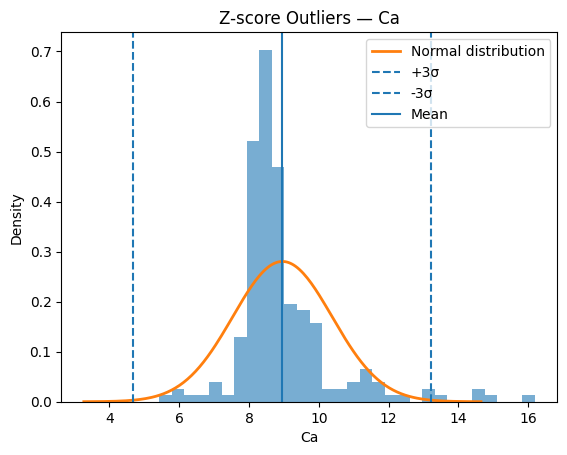

In [39]:
from scipy.stats import norm
column = "Ca"

mean = df[column].mean()
std = df[column].std()

plt.hist(
    df[column],
    bins=30,
    density=True,
    alpha=0.6
)

x = np.linspace(
    mean - 4*std,
    mean + 4*std,
    200
)

y = norm.pdf(x, mean, std)

plt.plot(
    x,
    y,
    linewidth=2,
    label="Normal distribution"
)

plt.axvline(
    mean + 3*std,
    linestyle="--",
    label="+3σ"
)

plt.axvline(
    mean - 3*std,
    linestyle="--",
    label="-3σ"
)

plt.axvline(
    mean,
    linestyle="-",
    label="Mean"
)

plt.xlabel(column)
plt.ylabel("Density")
plt.title(f"Z-score Outliers — {column}")
plt.legend()

plt.show()

### IQR Method

In [12]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

In [13]:
outliers_iqr = ((df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR)))

In [14]:
outliers = np.where(outliers_iqr)

In [15]:
outliers

(array([  5,  21,  32,  36,  38,  39,  44,  47,  50,  50,  56,  56,  61,
         71,  99, 100, 103, 103, 103, 104, 104, 105, 105, 105, 105, 106,
        106, 106, 106, 106, 106, 107, 107, 107, 108, 109, 109, 110, 110,
        110, 111, 111, 111, 112, 112, 118, 128, 130, 131, 131, 135, 141,
        142, 145, 161, 162, 163, 163, 163, 163, 163, 165, 166, 166, 167,
        169, 170, 170, 171, 171, 171, 172, 172, 172, 173, 174, 174, 175,
        175, 180, 182, 183, 184, 184, 184, 184, 184, 185, 185, 185, 185,
        185, 186, 186, 186, 186, 187, 187, 188, 188, 189, 189, 189, 189,
        189, 190, 190, 191, 191, 191, 192, 192, 192, 193, 193, 194, 194,
        195, 195, 195, 196, 196, 196, 197, 197, 197, 198, 198, 198, 199,
        199, 199, 200, 200, 201, 201, 201, 202, 202, 202, 203, 203, 204,
        204, 205, 205, 206, 206, 207, 207, 207, 207, 208, 208, 208, 209,
        209, 209, 210, 210, 211, 211, 212, 212, 213, 213]),
 array([8, 3, 7, 7, 3, 3, 8, 0, 0, 3, 0, 8, 7, 8, 7, 7, 0, 4, 6,

In [16]:
for i, j in zip(outliers[0], outliers[1]):
    print(
        f"Row: {df.index[i]}, "
        f"Column: {df.columns[j]}, "
        f"Value: {df.iloc[i, j]}"
    )

Row: 5, Column: Fe, Value: 0.26
Row: 21, Column: Al, Value: 0.29
Row: 32, Column: Ba, Value: 0.09
Row: 36, Column: Ba, Value: 0.11
Row: 38, Column: Al, Value: 0.47
Row: 39, Column: Al, Value: 0.47
Row: 44, Column: Fe, Value: 0.3
Row: 47, Column: RI, Value: 1.52667
Row: 50, Column: RI, Value: 1.5232
Row: 50, Column: Al, Value: 0.51
Row: 56, Column: RI, Value: 1.51215
Row: 56, Column: Fe, Value: 0.31
Row: 61, Column: Ba, Value: 0.69
Row: 71, Column: Fe, Value: 0.32
Row: 99, Column: Ba, Value: 0.14
Row: 100, Column: Ba, Value: 0.11
Row: 103, Column: RI, Value: 1.52725
Row: 103, Column: Si, Value: 70.57
Row: 103, Column: Ca, Value: 11.64
Row: 104, Column: RI, Value: 1.5241
Row: 104, Column: Ca, Value: 10.79
Row: 105, Column: RI, Value: 1.52475
Row: 105, Column: Na, Value: 11.45
Row: 105, Column: Ca, Value: 13.24
Row: 105, Column: Fe, Value: 0.34
Row: 106, Column: RI, Value: 1.53125
Row: 106, Column: Na, Value: 10.73
Row: 106, Column: Si, Value: 69.81
Row: 106, Column: Ca, Value: 13.3
Row: 

### Even Simpler Pandas approach we can do here

In [17]:
outlier_values = df[outliers_iqr].stack()
outlier_values

5    Fe      0.26
21   Al      0.29
32   Ba      0.09
36   Ba      0.11
38   Al      0.47
             ... 
211  Type    7.00
212  Ba      1.57
     Type    7.00
213  Ba      1.67
     Type    7.00
Length: 166, dtype: float64

Detecting more outliers doesn't automatically mean IQR is better, or that all those observations should be removed.

Outlier detection identifies unusual observations according to a statistical rule. Whether they are errors, valid extreme measurements, or important patterns requires further investigation.

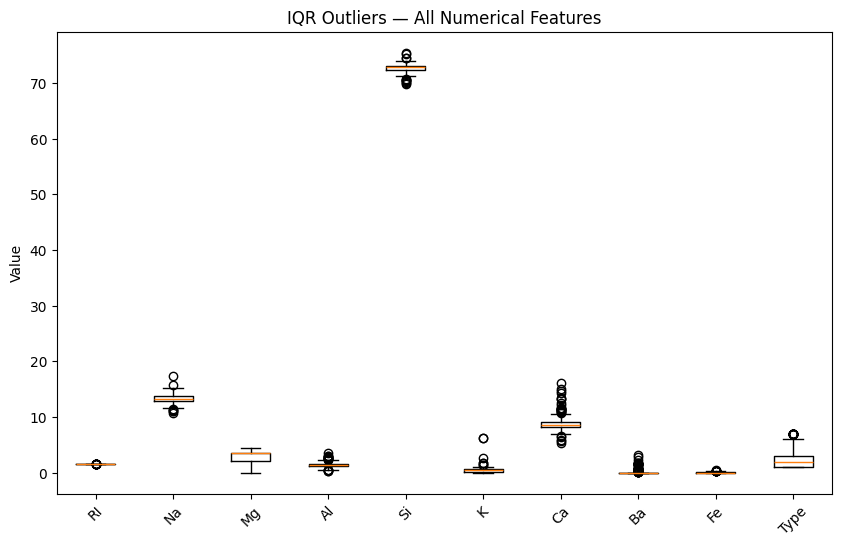

In [31]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [df[col].dropna() for col in df.columns],
    tick_labels=df.columns
)

plt.xticks(rotation=45)
plt.ylabel("Value")
plt.title("IQR Outliers — All Numerical Features")

plt.show();

### Isolation Forest

In [18]:
from sklearn.ensemble import IsolationForest

In [19]:
model = IsolationForest(
    contamination='auto',
    random_state=123
)

In [20]:
predictions = model.fit_predict(df)

In [21]:
predictions

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1, -1, -1,  1, -1, -1, -1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1, -1,  1,  1,  1,
        1, -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1,  1, -1, -1, -1, -1,
        1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1])

In [22]:
outliers = df[predictions == -1]
outliers

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
105,1.52475,11.45,0.00,1.88,72.19,0.81,13.24,0.00,0.34,2
106,1.53125,10.73,0.00,2.10,69.81,0.58,13.30,3.15,0.28,2
107,1.53393,12.30,0.00,1.00,70.16,0.12,16.19,0.00,0.24,2
109,1.51818,13.72,0.00,0.56,74.45,0.00,10.99,0.00,0.00,2
110,1.52664,11.23,0.00,0.77,73.21,0.00,14.68,0.00,0.00,2
111,1.52739,11.02,0.00,0.75,73.08,0.00,14.96,0.00,0.00,2
112,1.52777,12.64,0.00,0.67,72.02,0.06,14.40,0.00,0.00,2
131,1.52614,13.70,0.00,1.36,71.24,0.19,13.44,0.00,0.10,2
162,1.52211,14.19,3.78,0.91,71.36,0.23,9.14,0.00,0.37,3
163,1.51514,14.01,2.68,3.50,69.89,1.68,5.87,2.20,0.00,5


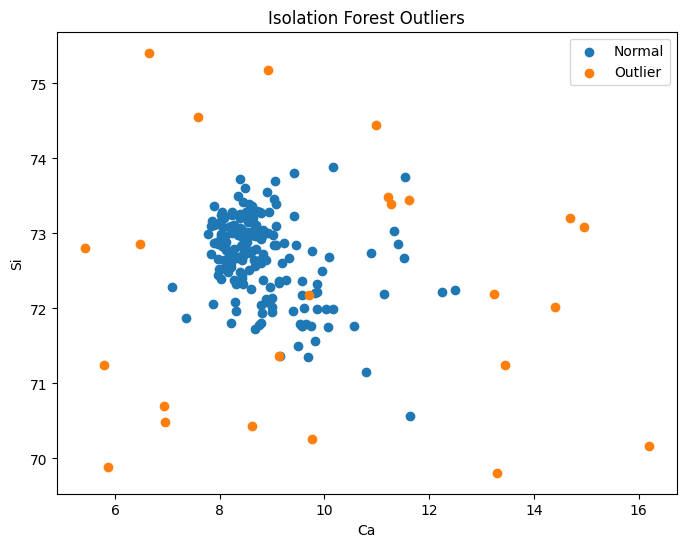

In [37]:
normal = predictions == 1
outlier = predictions == -1

plt.figure(figsize=(8, 6))

plt.scatter(
    df.loc[normal, "Ca"],
    df.loc[normal, "Si"],
    label="Normal"
)

plt.scatter(
    df.loc[outlier, "Ca"],
    df.loc[outlier, "Si"],
    label="Outlier"
)

plt.xlabel("Ca")
plt.ylabel("Si")
plt.title("Isolation Forest Outliers")
plt.legend()

plt.show()

### Local Outlier Factor (LOF)

In [40]:
from sklearn.neighbors import LocalOutlierFactor

In [41]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination='auto'
)

predictions = lof.fit_predict(df)

In [42]:
outliers = df[predictions == -1]

In [43]:
outliers

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.00,1
52,1.51808,13.43,2.87,1.19,72.84,0.55,9.03,0.00,0.00,1
53,1.51837,13.14,2.84,1.28,72.85,0.55,9.07,0.00,0.00,1
54,1.51778,13.21,2.81,1.29,72.98,0.51,9.02,0.00,0.09,1
55,1.51769,12.45,2.71,1.29,73.70,0.56,9.06,0.00,0.24,1
70,1.51574,14.86,3.67,1.74,71.87,0.16,7.36,0.00,0.12,2
84,1.51409,14.25,3.09,2.08,72.28,1.10,7.08,0.00,0.00,2
97,1.51743,12.20,3.25,1.16,73.55,0.62,8.90,0.00,0.24,2
101,1.51730,12.35,2.72,1.63,72.87,0.70,9.23,0.00,0.00,2
102,1.51820,12.62,2.76,0.83,73.81,0.35,9.42,0.00,0.20,2


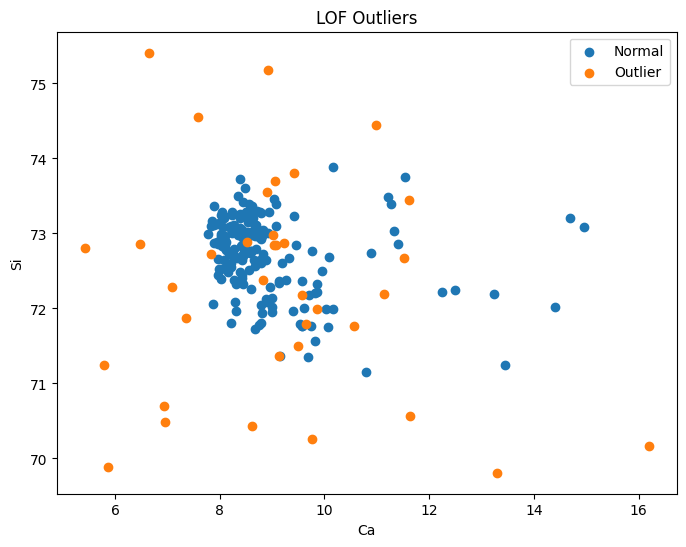

In [44]:
normal = predictions == 1
outlier = predictions == -1

plt.figure(figsize=(8, 6))

plt.scatter(
    df.loc[normal, "Ca"],
    df.loc[normal, "Si"],
    label="Normal"
)

plt.scatter(
    df.loc[outlier, "Ca"],
    df.loc[outlier, "Si"],
    label="Outlier"
)

plt.xlabel("Ca")
plt.ylabel("Si")
plt.title("LOF Outliers")
plt.legend()

plt.show()

* Isolation Forest:

       "Can I separate this point from the rest quickly?"

* LOF:

        "Does this point live in a much less dense neighborhood than the points around it?"